# Market Sentiment Classification
This notebook contains the experimental version of the project. It will cover:

1. Data loading and checking
2. Data exploration
3. Data preprocessing
4. Train/validation split
5. Feature engineering: BoW, TF-IDF, Word2Vec, Transformer Encoder
6. Classification models and evaluation
7. Final test prediction file generation
   
Labels: **0 = Bearish**, **1 = Bullish**, **2 = Neutral**.

# 1. Data Import

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import time


from main_lib import clean_text, stem_simple, preprocess_lemma, preprocess_stem
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [5]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (9543, 2)
Test shape: (2388, 2)


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [6]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['text', 'label']
Test columns: ['id', 'text']


# 2. EDA

In [8]:
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2388 non-null   int64
 1   text    2388 non-null   str  
dtypes: int64(1), str(1)
memory usage: 241.4 KB


In [9]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()

print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
id      0
text    0
dtype: int64


In [10]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [11]:
print("Duplicate texts in train:", train_df['text'].duplicated().sum())
print("Duplicate texts in test:", test_df['text'].duplicated().sum())

Duplicate texts in train: 0
Duplicate texts in test: 0


In [12]:
train_df['label'].value_counts().sort_index()

label
0    1442
1    1923
2    6178
Name: count, dtype: int64

In [13]:
train_df[10:20]

,text,label
10,$HOG - Moody's warns on Harley-Davidson https://t.co/LurHBEadeU,0
11,"$HXL - Citing aero ties, Wells slashes PT on Hexcel https://t.co/wU5P2i8WBU",0
12,$I - Intelsat cut to Market Perform at Raymond James https://t.co/YsvsMSQRIb,0
13,$KRG: Compass Point cuts to Sell https://t.co/MCyfTsXc2N,0
14,$LK - Muddy Waters goes short Luckin Coffee https://t.co/8yrbwAjLKG,0
15,$MANT - ManTech downgraded ahead of difficult comps https://t.co/mJ1eSrsFXJ,0
16,$MDCO: Oppenheimer cuts to Perform,0
17,$MPLX $MPC - MPLX cut at Credit Suisse on potential dilution from Marathon strategic review https://t.co/0BFQy4ZU6W,0
18,$MSGN - Imperial downgrades MSG Networks amid sports-free airwaves https://t.co/Ul2S6XNXw8,0
19,$MTLS - Piper hits the Materialise sidelines https://t.co/qlFxZuhkrt,0


In [14]:
label_map = {0:"Bearish", 1:"Bullish", 2:"Neutral"}
train_df['LabelName'] = train_df["label"].map(label_map)
label_table = pd.DataFrame({
    'count': train_df['LabelName'].value_counts(),
    'percentage': (train_df['LabelName'].value_counts(normalize=True) * 100).round(2),
})
display(label_table)

,count,percentage
LabelName,,
Neutral,6178,64.74
Bullish,1923,20.15
Bearish,1442,15.11


## Dependent feature

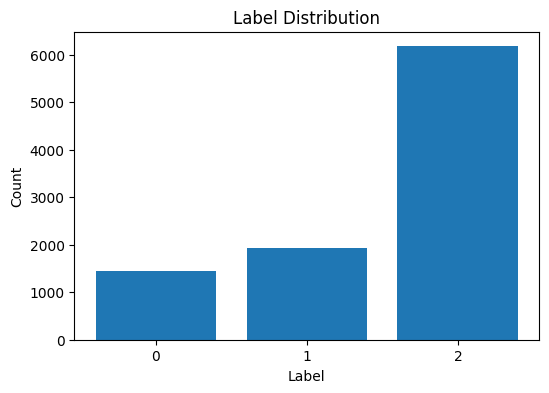

In [16]:
label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [17]:
train_df["TextLength"] = train_df['text'].astype(str).str.len()
train_df["WordCount"] = train_df['text'].astype(str).apply(lambda x:len(x.split()))
display(train_df[["TextLength","WordCount"]].describe())

display(train_df.groupby('LabelName')[["TextLength","WordCount"]].mean().round(2))

,TextLength,WordCount
count,9543.000000,9543.000000
mean,85.816934,12.178351
std,35.097229,4.665599
min,2.000000,1.000000
25%,58.000000,9.000000
50%,79.000000,11.000000
75%,120.000000,15.000000
max,190.000000,32.000000


,TextLength,WordCount
LabelName,,
Bearish,83.32,12.00
Bullish,80.38,11.93
Neutral,88.09,12.30


In [18]:
train_df

,text,label,LabelName,TextLength,WordCount
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,Bearish,77,10
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,Bearish,102,14
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,Bearish,94,14
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,Bearish,59,7
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,Bearish,71,10
...,...,...,...,...,...
9538,The Week's Gainers and Losers on the Stoxx Europe 50 --Dec. 2-6 #economy #MarketScreener https://t.co/iK5MO4NhQq https://t.co/AJh5V5fWTT,2,Neutral,136,16
9539,Tupperware Brands among consumer gainers; Unilever leads the losers,2,Neutral,67,9
9540,vTv Therapeutics leads healthcare gainers; Myomo and Biohaven Pharmaceutical among losers,2,Neutral,89,11
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral,47,9


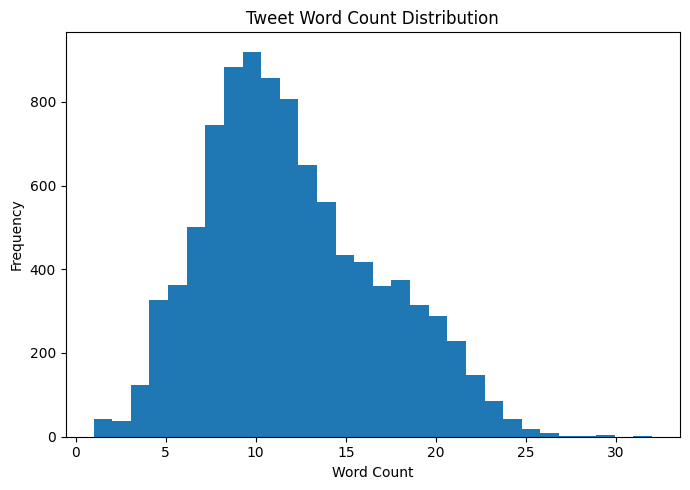

In [19]:
plt.figure(figsize=(7, 5))
train_df["WordCount"].plot(kind="hist", bins=30)
plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Data preprocessing

In [21]:
for df in [train_df, test_df]:
    df['CleanBasic'] = df['text'].apply(clean_text)
    df['CleanLemmatize'] = df['text'].apply(preprocess_lemma)
    df['CleanStmmer'] = df['text'].apply(preprocess_stem)
    df['TextLength'] = df['text'].astype(str).str.len()
    df['TextCount'] = df['text'].astype(str).apply(lambda x: len(str(x).split()))
display(train_df[['text','CleanBasic','CleanLemmatize','CleanStmmer']].head())

,text,CleanBasic,CleanLemmatize,CleanStmmer
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,bynd jpmorgan reels in expectations on beyond meat,bynd jpmorgan reel expectation meat,bynd jpmorgan reel expectation meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,ccl rcl nomura points to bookings weakness at carnival and royal caribbean,ccl rcl nomura point booking weakness carnival royal caribbean,ccl rcl nomura point booking weaknes carnival royal caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",cx cemex cut at credit suisse j p morgan on weak building outlook,cemex cut credit suisse morgan weak building outlook,cemex cut credit suisse morgan weak build outlook
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,ess btig research cuts to neutral,es btig research cut neutral,ess btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,fnko funko slides after piper jaffray pt cut,fnko funko slide piper jaffray cut,fnko funko slide piper jaffray cut


* Lemmatization is used for the final modeling text because it produces cleaner, more meaningful normalized tweets.

,word,frequency
0,stock,1341
1,market,571
2,marketscreener,480
3,new,417
4,report,403
5,price,394
6,say,393
7,result,382
8,earnings,352
9,share,343


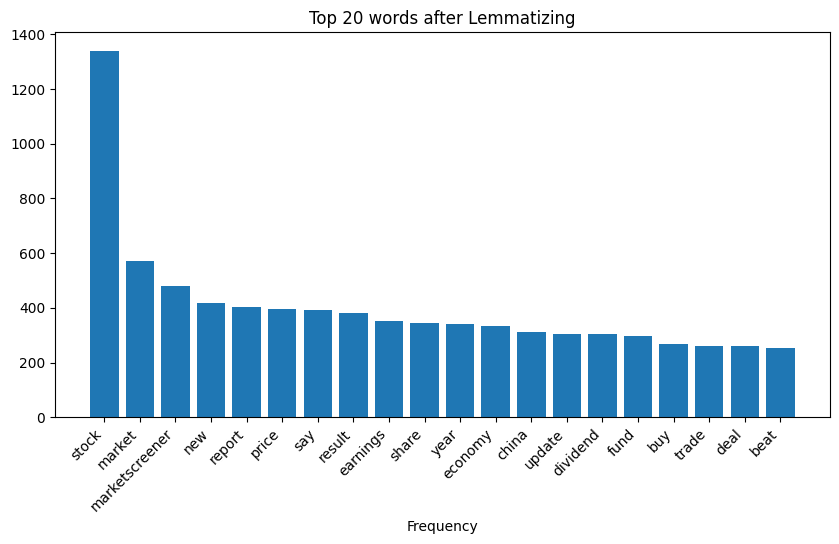

In [23]:
from collections import Counter
all_words = " ".join(train_df['CleanLemmatize'].fillna("")).split()
top_words = pd.DataFrame(Counter(all_words).most_common(20), columns=['word','frequency'])
display(top_words)
plt.figure(figsize=(10,5))
plt.bar(top_words['word'],top_words['frequency'])
plt.title("Top 20 words after Lemmatizing")
plt.xlabel("Word")
plt.xlabel("Frequency")
plt.xticks(rotation=45,ha='right')
plt.show()

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['CleanLemmatize'],
    train_df['label'],
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = train_df['label']
)

In [25]:
train_split = pd.DataFrame({
    "text" : train_df.loc[X_train.index,"text"] .values,
    "clean_text" : X_train.values,
    "label" : y_train.values,
})
val_split = pd.DataFrame({
    "text" : train_df.loc[X_val.index,"text"] .values,
    "clean_text" : X_val.values,
    "label" : y_val.values,
})

print("Total training split ",train_split.shape)
print("Total validation split ",val_split.shape)

# Training label distribution
print('Training label distribution :\n', train_split['label'].value_counts(normalize=True).round(3))
print("\n")
print('Validation label distribution :\n', val_split['label'].value_counts(normalize=True).round(3))

Total training split  (7634, 3)
Total validation split  (1909, 3)
Training label distribution :
 label
2    0.647
1    0.201
0    0.151
Name: proportion, dtype: float64


Validation label distribution :
 label
2    0.647
1    0.202
0    0.151
Name: proportion, dtype: float64


# Evaluation model

In [27]:
results = []
reports = {}
predictions = {}
def model_evaluation(name, model, X_trn=None, X_v=None, y_trn=None, y_v=None):
    if X_trn is None:
        X_trn, X_v, y_trn, y_v = X_train, X_val, y_train, y_val

    start = time.time()

    model.fit(X_trn, y_trn)
    pred = model.predict(X_v)

    end_time = time.time() - start

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="macro", zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_v, pred, average="weighted", zero_division=0
    )

    accuracy = accuracy_score(y_v, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Total_evaluation_time": end_time
    })
    reports[name] = classification_report(y_v, pred,target_names=['Bearish','Bullish','Neutral'], zero_division=0)
    predictions[name] = pred
    print(f"{name}: accuracy={accuracy:.4f}, macro_f1={macro_f1:.4f},  weighted_f1={weighted_f1:.4f}, end_time={end_time:.2f} ")
    return model

# Feature Engineering and classification models

In [29]:
bow_nb = Pipeline([
    ('bow',CountVectorizer(ngram_range=(1,2), min_df=2, max_features=50000)),
    ("clf", MultinomialNB(alpha=0.5))
])
model_evaluation(
    "BoW + MultinomialNB",
    bow_nb
)

BoW + MultinomialNB: accuracy=0.7968, macro_f1=0.7189,  weighted_f1=0.7928, end_time=0.11 


Pipeline(steps=[('bow',
                 CountVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf', MultinomialNB(alpha=0.5))])

In [30]:
models = {
    'TF-IDF + logisticRrgression' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear',C=1,class_weight='balanced',random_state=RANDOM_STATE)))
]),
    'TF-IDF + LinearSVC' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',LinearSVC(max_iter=3000, dual='auto', C=1,class_weight='balanced',random_state=RANDOM_STATE))
]),
    'TF-IDF word+char + LinearSVC' : Pipeline([
        ('features', FeatureUnion([
            ('word',TfidfVectorizer(analyzer='word',ngram_range=(1,2), min_df=2,sublinear_tf=True, max_features=50000)),
            ('char',TfidfVectorizer(analyzer='char_wb',ngram_range=(2,3), min_df=2,sublinear_tf=True, max_features=50000)),
        ])),
        ('clf',LinearSVC(max_iter=3000, dual='auto', C=0.5,class_weight='balanced',random_state=RANDOM_STATE))
]),
    'TF-TDF + SGDClassifier' : Pipeline([
    ("tfidf",TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000)),
    ('clf',SGDClassifier(loss="modified_huber",alpha=1e-5,max_iter=3000,class_weight='balanced',random_state=RANDOM_STATE))
])
    }
trained_models = {}
for name, model in models.items():
    trained_models[name] = model_evaluation(name,model)


TF-IDF + logisticRrgression: accuracy=0.7994, macro_f1=0.7319,  weighted_f1=0.7994, end_time=0.14 
TF-IDF + LinearSVC: accuracy=0.7988, macro_f1=0.7241,  weighted_f1=0.7963, end_time=0.14 
TF-IDF word+char + LinearSVC: accuracy=0.8025, macro_f1=0.7324,  weighted_f1=0.8004, end_time=0.56 
TF-TDF + SGDClassifier: accuracy=0.7763, macro_f1=0.6942,  weighted_f1=0.7716, end_time=0.12 


# Word2Vec

In [31]:
sentences = [text.split() for text in train_split['clean_text'].fillna("")]
w2v = Word2Vec(
    sentences = sentences,
    window=5,
    vector_size=80,
    min_count=2,
    workers=2,
    sg=1,
    seed = RANDOM_STATE,
    epochs=10
)

def average_word2vec(texts):
    vectors = np.zeros((len(texts), w2v.vector_size), dtype=np.float32)
    for i, text in enumerate(texts):
        token_vectors = [w2v.wv[word] for word in str(text).split() if word in w2v.wv]
        if token_vectors:
            vectors[i] = np.mean(token_vectors, axis=0)
    return vectors
    
X_train_w2v = average_word2vec(train_split['clean_text'])
X_val_w2v = average_word2vec(val_split['clean_text'])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [32]:
w2v_lr = Pipeline([
    ('scale', StandardScaler()),
    ('clf',LogisticRegression(max_iter=1000, class_weight='balanced',random_state=RANDOM_STATE))
])
model_evaluation("Word2Vec avg + LogisticRegression",w2v_lr,X_train_w2v,X_val_w2v, y_train, y_val)

w2v_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=1,
    max_depth=20
)
model_evaluation("Word2Vec avg + RandomForestClassifier",w2v_rf, X_train_w2v, X_val_w2v, y_train, y_val)

Word2Vec avg + LogisticRegression: accuracy=0.6506, macro_f1=0.5683,  weighted_f1=0.6664, end_time=69.62 
Word2Vec avg + RandomForestClassifier: accuracy=0.7334, macro_f1=0.5760,  weighted_f1=0.7039, end_time=3.68 


RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       n_jobs=1, random_state=42)

# Evaluation and analysis

In [34]:
results_df = pd.DataFrame(results).sort_values('Macro F1',ascending=False)
display(results_df)
best_model_name = results_df.iloc[0]['Model']
print("Best validation model: ",best_model_name)
print("----------------------------------------")
print("\nClassification report: ")
print(reports[best_model_name])

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total_evaluation_time
3,TF-IDF word+char + LinearSVC,0.802514,0.741689,0.724085,0.732359,0.800401,0.560340
1,TF-IDF + logisticRrgression,0.799371,0.731956,0.731966,0.731949,0.799371,0.140142
2,TF-IDF + LinearSVC,0.798848,0.734836,0.714790,0.724132,0.796302,0.137369
0,BoW + MultinomialNB,0.796752,0.735223,0.705405,0.718915,0.792794,0.113339
4,TF-TDF + SGDClassifier,0.776323,0.712293,0.679718,0.694193,0.771568,0.117369
6,Word2Vec avg + RandomForestClassifier,0.733368,0.669164,0.546342,0.575996,0.703864,3.677151
5,Word2Vec avg + LogisticRegression,0.650602,0.558536,0.593572,0.568251,0.666381,69.616993


Best validation model:  TF-IDF word+char + LinearSVC
----------------------------------------

Classification report: 
              precision    recall  f1-score   support

     Bearish       0.64      0.61      0.63       288
     Bullish       0.72      0.67      0.70       385
     Neutral       0.86      0.89      0.87      1236

    accuracy                           0.80      1909
   macro avg       0.74      0.72      0.73      1909
weighted avg       0.80      0.80      0.80      1909



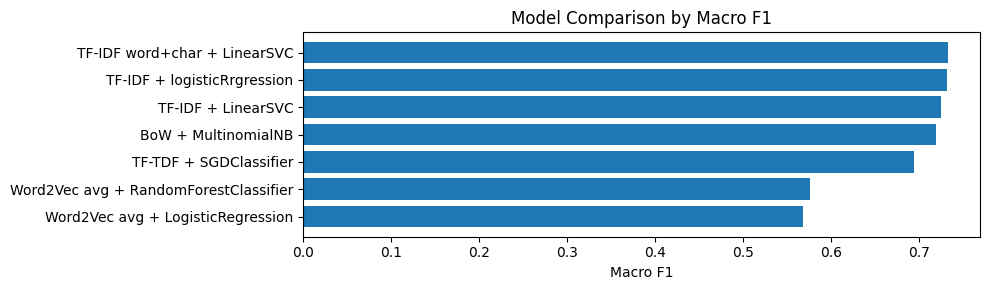

In [35]:
plt.figure(figsize=(10, 3))
plot_df = results_df.sort_values("Macro F1")
plt.barh(plot_df["Model"], plot_df["Macro F1"])
plt.title("Model Comparison by Macro F1")
plt.xlabel("Macro F1")
plt.tight_layout()
plt.show()

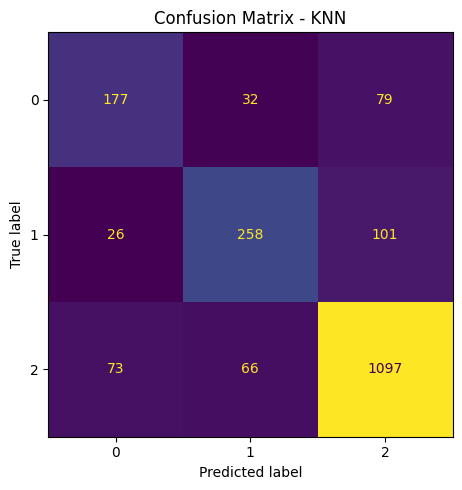

In [114]:
# Compute the confusion matrix
cm = confusion_matrix(y_val, predictions[best_model_name], labels=[0,1,2])

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()